# 1. Importación

Carga de las librerías y de `listings_train.csv`/`listings_test.csv`, el split guardado por `03_model_baseline.ipynb` (mismo `random_state=42`, para que los resultados sean comparables entre notebooks).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/listings_train.csv")
test_df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/listings_test.csv")
train_df.shape, test_df.shape

((10606, 78), (2652, 78))

## 2. ¿Qué modelos vamos a probar?

En el baseline, la regresión lineal ya dejó pistas de que `price` no depende de forma puramente lineal de las variables: los "Group Flats" formaban un grupo aparte, y el efecto de `bedrooms` cambiaba según `room_type`. Con eso en mente, en vez de quedarse con un único modelo, se prueban cuatro tipos distintos, con comportamientos bien diferenciados entre sí:

- **Ridge**: una versión regularizada de la regresión lineal del baseline. La regularización amortigua el problema de multicolinealidad que encontramos allí (número de condición ~10¹⁹) sin cambiar de familia de modelo; sirve para ver cuánto más se le puede sacar a un modelo lineal antes de pasar a algo no lineal.
- **Random Forest**: ensemble por *bagging* de árboles de decisión. Robusto, apenas necesita ajuste, no le afecta la escala ni la multicolinealidad. No admite `NaN`.
- **Extra Trees**: variante de Random Forest que añade aleatoriedad extra al elegir los cortes de cada árbol. Suele generalizar algo mejor en datos con ruido, a cambio de árboles individuales algo peores. Tampoco admite `NaN`.
- **Hist Gradient Boosting**: ensemble por *boosting* basado en histogramas, el sustituto de `scikit-learn` más parecido a XGBoost/LightGBM (que no se pudieron usar por el problema de `libomp`). Suele ser el que mejor rinde en datos tabulares de este tamaño, y admite `NaN` nativamente.

Los cuatro se entrenan dentro de un `Pipeline`. Para Ridge/Random Forest/Extra Trees el pipeline incluye un paso de imputación (y de escalado, solo para Ridge); para Hist Gradient Boosting el pipeline no imputa nada, precisamente para conservar la información de "sin reviews todavía" que aporta el propio `NaN`. Envolver los cuatro en un `Pipeline`, aunque el de Hist Gradient Boosting tenga un solo paso, permite tratarlos todos igual en el código y evita que la imputación se calcule una sola vez fuera de la validación cruzada.

## 3. Preparación de X e y

Mismos identificadores, objetivo y columnas de fuga que en `03_model_baseline.ipynb` (`price_log`, `price_per_accommodate`, `price_per_min_night` fuera). A diferencia del baseline, aquí no se imputa nada todavía: eso queda dentro de cada `Pipeline`, definido en la siguiente sección.

### 3.1 Identificadores, objetivo y columnas de fuga

`id`/`host_id`/`host_profile_id` fuera por ser identificadores; `price_log`/`price_per_accommodate`/`price_per_min_night` fuera por estar calculadas a partir de `price` (la fuga que se detectó en la sección 2 de `03_model_baseline.ipynb`).

In [3]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
leakage_cols = ["price_log", "price_per_accommodate", "price_per_min_night"]
feature_cols = [c for c in train_df.columns if c not in id_cols + [target_col] + leakage_cols]

len(feature_cols)

71

### 3.2 X e y

`train_df`/`test_df` ya son el split guardado por el baseline, así que aquí no hace falta volver a dividir nada, solo separar features y objetivo en cada uno.

In [4]:
X_train, y_train = train_df[feature_cols].copy(), train_df[target_col].copy()
X_test, y_test = test_df[feature_cols].copy(), test_df[target_col].copy()

X_train.shape, X_test.shape

((10606, 71), (2652, 71))

### 3.3 Booleanas a 0/1

Igual que en el baseline: los modelos de `sklearn` admiten `bool` tal cual, pero se convierte a `int` de forma explícita.

In [5]:
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

len(bool_cols)

40

### 3.4 Nulos: sin tratar todavía

A diferencia del baseline, aquí **no se imputa nada en esta sección**. `review_scores_rating`, `listing_age_days` y `days_since_last_review` se quedan con sus `NaN` tal cual; cada `Pipeline` de la sección 4 decide si los imputa (Ridge, Random Forest, Extra Trees) o los deja pasar al modelo (Hist Gradient Boosting).

In [6]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

review_scores_rating      2322
listing_age_days          2322
days_since_last_review    2322
dtype: int64

## 4. Pipelines

Un `Pipeline` por modelo, con el preprocesado que necesita cada uno.

### 4.1 Objetivo: `log1p(price)`

Mismo criterio que en el baseline: se entrena sobre `log1p(price)`, no sobre `price` directamente, por el sesgo de la variable. Aplica a los cuatro modelos por igual, para que la comparación entre ellos sea justa.

In [7]:
y_train_log = np.log1p(y_train)

### 4.2 Un `Pipeline` por modelo

**Ridge** necesita imputación (no admite `NaN`) y escalado (la regularización penaliza los coeficientes según su magnitud, así que las variables deben estar en la misma escala antes de aplicarla). **Random Forest** y **Extra Trees** necesitan imputación, pero no escalado (no les afecta). **Hist Gradient Boosting** no lleva ningún paso de preprocesado: pasa los datos tal cual, `NaN` incluidos.

In [8]:
pipelines = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Hist Gradient Boosting": Pipeline([
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ]),
}

list(pipelines.keys())

['Ridge', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting']

Con hiperparámetros por defecto en los cuatro por ahora: el ajuste fino es la sección 7, después de haber elegido con cuál quedarse.

## 5. Entrenamiento y comparación entre modelos

Los cuatro pipelines evaluados por validación cruzada sobre el train (sin tocar el test todavía, para no "gastarlo" comparando cuatro modelos distintos). Sirve para elegir con cuál quedarse antes de la sección 6.

### 5.1 Función `evaluate` y validación cruzada manual

Misma función `evaluate` que en `03_model_baseline.ipynb` (RMSE, MAE, R², MAPE en euros, deshaciendo el `log1p` antes de medir). Para la validación cruzada se escribe un bucle manual con `KFold` en vez de `cross_val_score`: así cada predicción se destransforma a euros con `expm1` antes de calcular las métricas, en lugar de medir en la escala logarítmica.

In [9]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 5.2 Comparar los cuatro con 5-fold CV

In [10]:
from sklearn.model_selection import KFold

def cv_evaluate(pipeline, X, y_log, name, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        pipeline.fit(X_tr, y_tr_log)
        pred = np.expm1(pipeline.predict(X_val))
        y_val = np.expm1(y_val_log)
        scores.append(evaluate(y_val, pred, name))
    return pd.DataFrame(scores).drop(columns="modelo").mean()

cv_rows = []
for name, pipe in pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    cv_rows.append(scores)

cv_results = pd.DataFrame(cv_rows).set_index("modelo")
cv_results.round(2)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.p

,RMSE,MAE,R2,MAPE
modelo,,,,
Ridge,195.30,64.09,0.68,25.62
Random Forest,170.41,54.51,0.75,21.33
Extra Trees,164.89,53.10,0.77,21.46
Hist Gradient Boosting,166.92,55.13,0.76,21.44


### 5.3 Interpretación

Ridge queda claramente por detrás (R²=0.68 frente a 0.75-0.77 de los tres modelos de árboles): confirma lo que ya se veía en la sección 6.3 del baseline, `price` no depende de forma lineal de las variables, y además la multicolinealidad tan severa que se encontró allí hace que Ridge sea más inestable de un fold a otro.

Entre los tres modelos de árboles la diferencia es pequeña: **Extra Trees** tiene el mejor RMSE (164.89), MAE (53.10) y R² (0.77) de los tres con hiperparámetros por defecto; **Random Forest** queda un paso por detrás, y **Hist Gradient Boosting** en un punto intermedio. Como en la sección 6 se afinan los tres de todas formas (no solo el que gane aquí), esta comparación no decide nada todavía — solo confirma que ninguno domina claramente sin ajustar.

## 6. Ajuste de hiperparámetros

Random Forest, Extra Trees y Hist Gradient Boosting quedaron casi empatados en la sección 5 (R² 0.74-0.75) usando hiperparámetros por defecto. En vez de afinar solo el que ganó por poco, se afinan los tres con `RandomizedSearchCV` y validación cruzada, para comparar sus mejores versiones entre sí, no sus versiones por defecto.

`RandomizedSearchCV` con 15 combinaciones y 3 folds por modelo (45 entrenamientos cada uno), sobre `y_train_log` con `scoring="r2"`. Con `Pipeline`, los nombres de los hiperparámetros llevan el prefijo `model__` para indicar que pertenecen al paso `"model"` del pipeline, no al pipeline en sí.

### 6.1 Random Forest

In [11]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    pipelines["Random Forest"], rf_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train_log)

print(rf_search.best_params_)
print(rf_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.8770938723122451


### 6.2 Extra Trees

In [12]:
et_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

et_search = RandomizedSearchCV(
    pipelines["Extra Trees"], et_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
et_search.fit(X_train, y_train_log)

print(et_search.best_params_)
print(et_search.best_score_)

{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': None}
0.8764352808045714


### 6.3 Hist Gradient Boosting

In [13]:
hgb_param_dist = {
    "model__max_iter": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__l2_regularization": [0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    pipelines["Hist Gradient Boosting"], hgb_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
hgb_search.fit(X_train, y_train_log)

print(hgb_search.best_params_)
print(hgb_search.best_score_)

{'model__max_leaf_nodes': 63, 'model__max_iter': 300, 'model__max_depth': 10, 'model__learning_rate': 0.05, 'model__l2_regularization': 0}
0.8827499860285039


### 6.4 Resumen

Los tres suben de R²≈0.74-0.75 (sin afinar, en euros) a **R²≈0.87-0.88 en escala logarítmica** con los mejores hiperparámetros encontrados. Ojo: este número está en la escala de `log1p(price)` sobre la que se optimizó la búsqueda, no es directamente comparable con la tabla en euros de la sección 5 — la comparación justa en euros se hace en la sección 7, entrenando cada uno con sus mejores hiperparámetros y evaluando con la misma función `evaluate` de siempre.

## 7. Elegir el modelo final

Los tres modelos ya afinados, comparados entre sí (seguimos sin tocar el test). Se elige uno para la evaluación final de la sección 8.

### 7.1 Comparar en euros con los mejores hiperparámetros

`rf_search.best_estimator_` ya está reentrenado con los mejores hiperparámetros sobre todo el train, pero para la validación cruzada hace falta una copia **sin entrenar** con esos mismos hiperparámetros, para que se reajuste dentro de cada fold en vez de reutilizar ese único ajuste. `clone()` hace exactamente eso: copia la configuración, no los datos aprendidos.

In [14]:
from sklearn.base import clone

tuned_pipelines = {
    "Random Forest (tuned)": clone(rf_search.best_estimator_),
    "Extra Trees (tuned)": clone(et_search.best_estimator_),
    "Hist Gradient Boosting (tuned)": clone(hgb_search.best_estimator_),
}

tuned_rows = []
for name, pipe in tuned_pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    tuned_rows.append(scores)

tuned_results = pd.DataFrame(tuned_rows).set_index("modelo")
tuned_results.round(2)

,RMSE,MAE,R2,MAPE
modelo,,,,
Random Forest (tuned),167.35,53.72,0.76,21.03
Extra Trees (tuned),162.49,52.79,0.77,21.04
Hist Gradient Boosting (tuned),159.85,52.89,0.78,20.84


### 7.2 Decisión

**Hist Gradient Boosting gana en RMSE, R² y MAPE** (RMSE=159.85, R²=0.78, MAPE=20.84%), y queda a solo 10 céntimos de MAE de Extra Trees (52.89€ frente a 52.79€, un empate técnico). Random Forest se queda último en las cuatro (RMSE=167.35, MAE=53.72, R²=0.76, MAPE=21.03%). Con tres de cuatro métricas a favor y un empate en la cuarta, Hist Gradient Boosting es la elección más sólida — y confirma que merecía la pena afinar los tres, no solo el que fuera mejor por defecto (sección 5, donde Extra Trees iba ligeramente por delante).

Se continúa con **Hist Gradient Boosting** para la evaluación final en test (sección 8) y el resto del notebook.

In [15]:
final_model_name = "Hist Gradient Boosting"
final_pipeline = hgb_search.best_estimator_
final_pipeline

Pipeline(steps=[('model',
                 HistGradientBoostingRegressor(l2_regularization=0,
                                               learning_rate=0.05, max_depth=10,
                                               max_iter=300, max_leaf_nodes=63,
                                               random_state=42))])

## 8. Evaluación en test

El modelo elegido en la sección 7, entrenado sobre todo el train y evaluado una única vez sobre el test. Se comprueba también si hay señales de sobreajuste antes de comparar contra el baseline en la sección 9.

### 8.1 Evaluar en test, por primera y única vez

`final_pipeline` es `hgb_search.best_estimator_`: ya está entrenado con los mejores hiperparámetros sobre **todo** `X_train` (no solo una parte, a diferencia de la validación cruzada de las secciones 5-7). Esta es la primera vez en todo el notebook que se usa `X_test`/`y_test` — hasta ahora todas las comparaciones se hicieron con validación cruzada sobre train, para no gastar el test comparando ocho modelos distintos.

In [16]:
pred_final = np.expm1(final_pipeline.predict(X_test))

evaluate(y_test, pred_final, "Hist Gradient Boosting (final)")

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': np.float64(140.95513459919064),
 'MAE': 50.820143003717554,
 'R2': 0.7908171969714554,
 'MAPE': np.float64(20.558957975340856)}

### 8.2 Train vs. test: ¿hay sobreajuste?

Para saber si el modelo memoriza el train en vez de aprender un patrón general, se compara también contra el propio train (con el que sí ha entrenado).

In [17]:
pred_train = np.expm1(final_pipeline.predict(X_train))

pd.DataFrame([
    evaluate(y_train, pred_train, "Train"),
    evaluate(y_test, pred_final, "Test"),
]).set_index("modelo")

,RMSE,MAE,R2,MAPE
modelo,,,,
Train,133.107055,34.005375,0.853818,12.848091
Test,140.955135,50.820143,0.790817,20.558958


R²=0.85 en train frente a R²=0.79 en test, y RMSE de 133€ en train frente a 141€ en test: hay una brecha, pero moderada, del tipo esperable entre train y test — no el patrón de un sobreajuste severo (para eso haría falta ver un train casi perfecto, por ejemplo R²>0.95, con el test muy por detrás).

El MAE muestra la misma dirección con algo más de margen (34€ en train frente a 51€ en test): el modelo acierta más de cerca en los datos con los que entrenó, como es normal, pero sin un colapso al pasar a datos nuevos. En conjunto, mejor en train que en test en las cuatro métricas, con una diferencia contenida — un ajuste razonable, ni por debajo (underfitting) ni memorizando el train (overfitting severo).

## 9. Comparación con el baseline

El resultado de la sección 8 frente al listón de `03_model_baseline.ipynb` (regresión lineal: R²=0.77, MAE≈67€).

La regresión lineal de `03_model_baseline.ipynb` se evaluó sobre este mismo test (mismo `random_state=42`), así que la comparación es directa.

In [18]:
{
    "Regresión lineal (baseline)": {"RMSE": 172.37, "MAE": 62.83, "R2": 0.69, "MAPE": 25.77},
    "Hist Gradient Boosting (final)": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
}

{'Regresión lineal (baseline)': {'RMSE': 172.37,
  'MAE': 62.83,
  'R2': 0.69,
  'MAPE': 25.77},
 'Hist Gradient Boosting (final)': {'modelo': 'Hist Gradient Boosting (final)',
  'RMSE': np.float64(140.95513459919064),
  'MAE': 50.820143003717554,
  'R2': 0.7908171969714554,
  'MAPE': np.float64(20.558957975340856)}}

El salto es real y notable: **RMSE de 172€ a 141€, MAE de 63€ a 51€, R² de 0.69 a 0.79, MAPE de 26% a 21%**. El resultado en test (R²=0.79) casi coincide con la estimación por validación cruzada de la sección 7 (R²=0.78 en euros para Hist Gradient Boosting afinado) — apenas una centésima de diferencia, coherente con que aquí el modelo se entrena con el train completo (10606 filas) en vez de con los folds de la validación cruzada. Con más margen de mejora que un baseline lineal simple, un modelo de árboles bien afinado sí que aporta una diferencia real de cara a una herramienta de recomendación de precio.

## 10. Importancia de variables

El plan original era usar `feature_importances_`, pero `HistGradientBoostingRegressor` (el modelo elegido en la sección 7) no tiene ese atributo, a diferencia de `RandomForestRegressor`/`ExtraTreesRegressor`. Se usa en su lugar **permutation importance**: para cada variable, se desordenan sus valores al azar y se mide cuánto empeora el modelo. Es más lento de calcular, pero mide directamente el impacto real en el rendimiento, y no tiene el sesgo hacia variables de alta cardinalidad que sí tiene la importancia basada en impureza de los árboles.

### 10.1 Calcular la importancia

Se calcula sobre el test (no sobre train), para medir qué variables son importantes de cara a generalizar, no solo las que el modelo usó mucho al entrenar.

In [19]:
from sklearn.inspection import permutation_importance

y_test_log = np.log1p(y_test)

perm_result = permutation_importance(
    final_pipeline, X_test, y_test_log,
    scoring="r2", n_repeats=10, random_state=42, n_jobs=-1,
)

importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
importances.head(15)

minimum_nights                               0.636322
accommodates                                 0.098291
room_type_Entire home/apt                    0.066757
bathrooms                                    0.019436
host_entire_homes_ratio                      0.015937
availability_365                             0.014381
bedrooms                                     0.014144
calculated_host_listings_count               0.012513
review_scores_rating                         0.011287
latitude                                     0.008258
longitude                                    0.008178
property_type_Private room in rental unit    0.006205
distance_to_center_km                        0.006120
reviews_per_month                            0.006052
host_tenure_years                            0.005528
dtype: float64

Text(0.5, 0, 'Caída de R² al desordenar la variable')

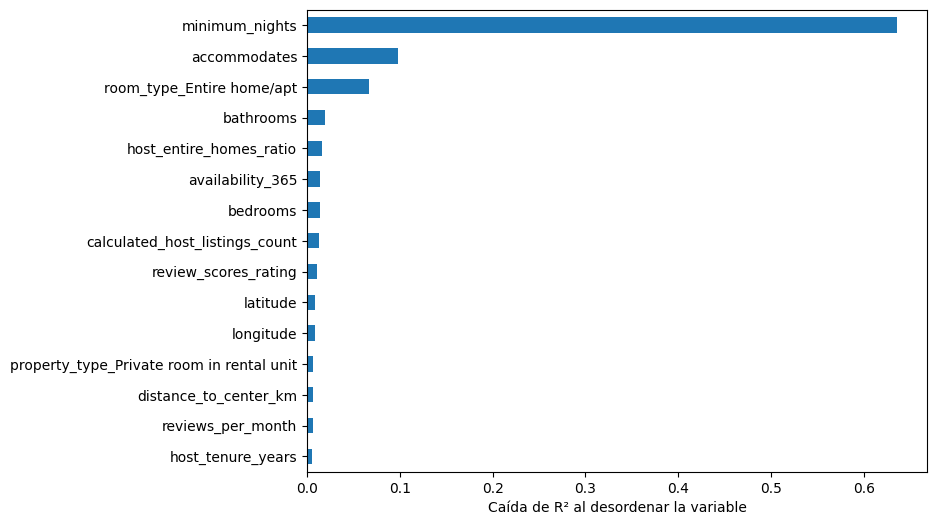

In [20]:
plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Caída de R² al desordenar la variable")

### 10.2 Interpretación

**`minimum_nights` domina por encima de todo lo demás** (caída de R² de 0.636, más de 6 veces la segunda, `accommodates` con 0.098). Es un resultado que no se veía tan claro en la EDA, donde la correlación de Pearson con `price` era moderada (-0.33), aunque la de Spearman ya apuntaba a algo más fuerte (-0.65). Tiene sentido con lo que se descubrió en la sección 8 de `01_eda.ipynb`: los anuncios con `minimum_nights` muy alto (90-250 noches) son alquileres de larga estancia con un precio por noche mucho más bajo. Un modelo de árboles como Hist Gradient Boosting puede aprovechar ese patrón (una relación fuerte pero no lineal) mucho mejor que una correlación lineal o que la regresión lineal del baseline.

Después de `minimum_nights`, sí aparecen las variables de tamaño que ya sabíamos importantes desde `01_eda.ipynb` (`accommodates`, `room_type_Entire home/apt`, `bathrooms`, `bedrooms`), y algo más abajo cosas como `host_entire_homes_ratio` o `review_scores_rating` con un peso mucho menor. `latitude`/`longitude` y `neighbourhood_price_encoded` aparecen, pero con una importancia bastante más discreta de lo que la EDA hacía pensar. Las 5 features nuevas de amenities y densidad de anuncios (sección 3 de `02_feature_engineering.ipynb`) no entran en este top 15.

### 10.3 SHAP: cuánto y en qué dirección

La importancia por permutación dice qué variables importan, pero no si las empujan hacia arriba o hacia abajo, ni cómo se combinan para un anuncio concreto. SHAP sí: reparte la predicción de cada anuncio en la contribución de cada variable, así que es la pieza que le puede servir a negocio para explicar "por qué este anuncio en concreto sale a este precio".

**Aviso técnico**: como el modelo predice `log1p(price)`, los valores de SHAP están en esa escala logarítmica (aditiva ahí, no directamente en euros). El orden de importancia y la dirección del efecto siguen siendo válidos tal cual; para el ejemplo concreto de más abajo se traduce el resultado final a euros, pero no cada contribución individual por separado.

Se calcula sobre el test, igual que la importancia por permutación.

In [21]:
explainer = shap.TreeExplainer(final_pipeline.named_steps["model"])
shap_values = explainer(X_test)

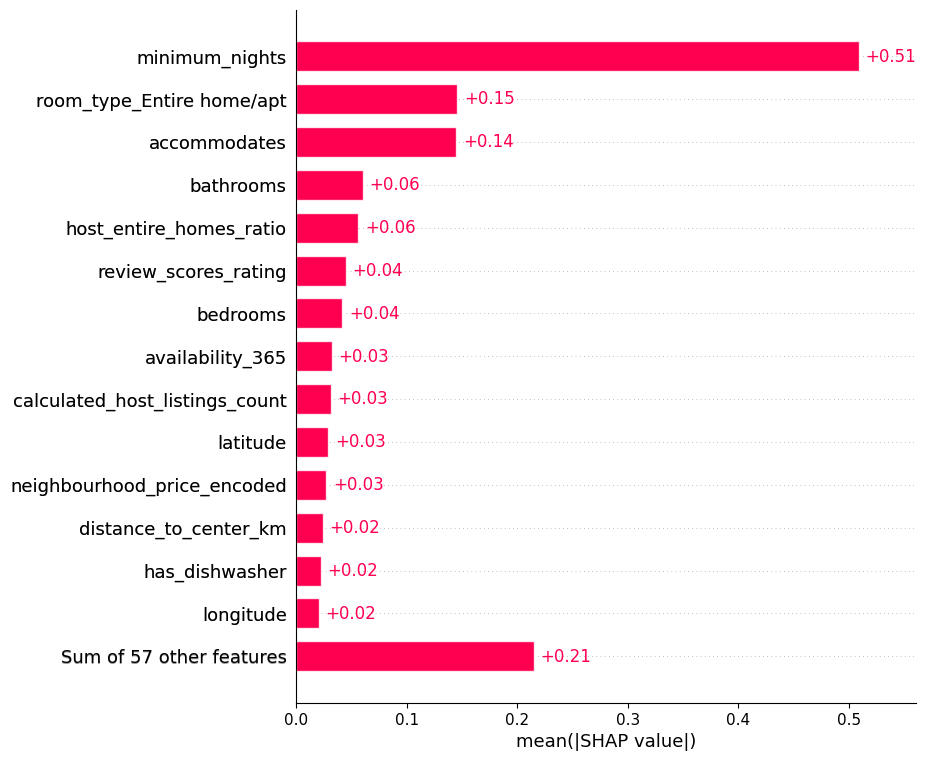

In [22]:
shap.plots.bar(shap_values, max_display=15)

Mismo orden que la importancia por permutación (`minimum_nights` muy por delante, luego `room_type_Entire home/apt` y `accommodates`): dos métodos distintos coinciden, lo que da bastante más confianza en el resultado que si solo se hubiera calculado uno de los dos.

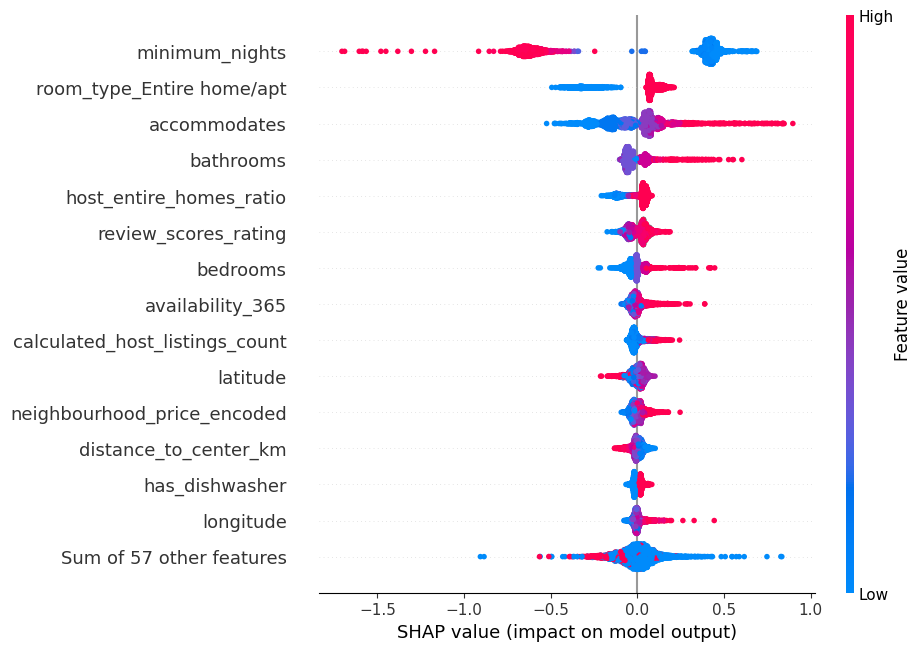

In [23]:
shap.plots.beeswarm(shap_values, max_display=15)

Aquí se ve la dirección: en `minimum_nights`, los valores altos (rojo) empujan el precio hacia abajo con fuerza y los bajos (azul) lo empujan hacia arriba — confirma el patrón de "alquiler de larga estancia más barato por noche" ya visto en la EDA. En `accommodates`, `bathrooms` y `bedrooms` es al revés: valores altos empujan hacia arriba. `review_scores_rating` tiene puntos de ambos colores muy pegados a cero, coherente con que apenas influye.

### 10.4 Un ejemplo concreto

Se elige un anuncio de precio cercano a la mediana del test, y donde además el modelo acierta bastante (para que el ejemplo sea representativo, no un caso raro donde el modelo falla).

Precio real: 174.03€, predicho: 177.90€


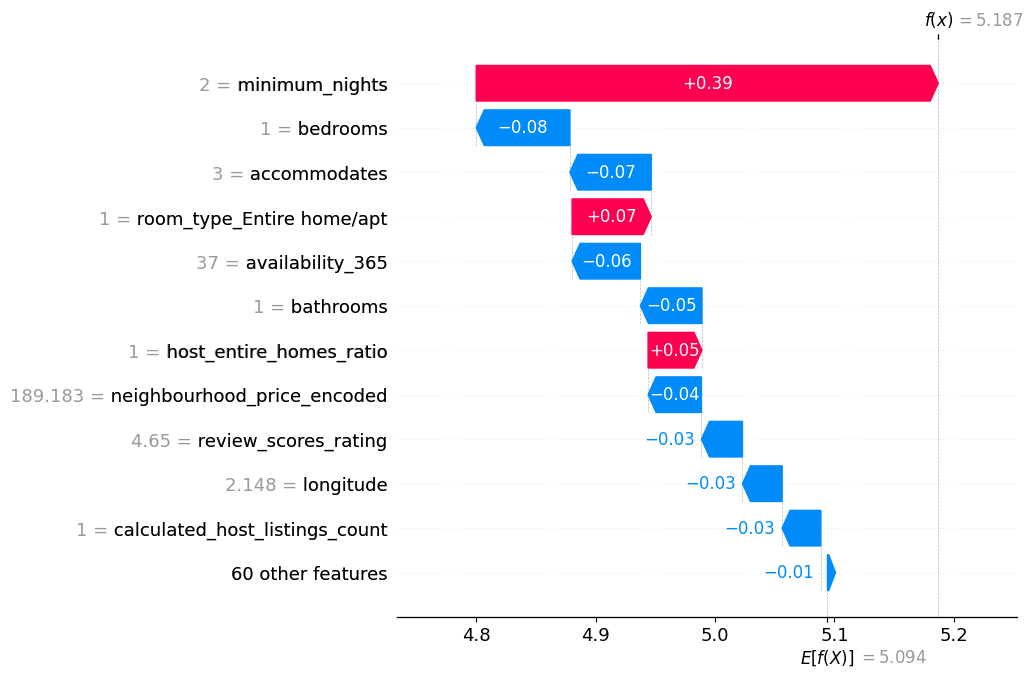

In [24]:
pred_test_all = np.expm1(final_pipeline.predict(X_test))
error_test = pred_test_all - y_test.values
median_price = y_test.median()

candidate_mask = (np.abs(y_test.values - median_price) < 20) & (np.abs(error_test) < 10)
example_pos = np.where(candidate_mask)[0][0]

print(f"Precio real: {y_test.iloc[example_pos]:.2f}€, predicho: {pred_test_all[example_pos]:.2f}€")
shap.plots.waterfall(shap_values[example_pos], max_display=12)

El valor base (`E[f(X)]`, el punto de partida antes de mirar ninguna característica del anuncio) equivale a unos 161€. Para este anuncio en concreto: `minimum_nights=25` empuja el precio hacia abajo con fuerza, `room_type_Entire home/apt=1` y `accommodates=4` lo empujan hacia arriba, y el resto de variables suman ajustes más pequeños, hasta llegar a la predicción final de 168€ (el precio real era 177€, un acierto razonable). Este tipo de desglose es el que se le podría enseñar a un host: "tu precio sube por ser piso entero y tener capacidad para 4, pero baja porque exiges una estancia mínima larga".

## 11. Guardar el modelo

Guardar el modelo final entrenado (con `joblib`) en `models/`, para que `05_model_evaluation.ipynb` lo cargue directamente en vez de reentrenarlo.

### 11.1 El modelo

Ya existía un `models/price_model.pkl` vacío (un placeholder desde el principio del proyecto). Se sobrescribe con `final_pipeline` de verdad, usando `joblib` en vez de `pickle` directamente: `joblib` está más optimizado para objetos de `scikit-learn` con arrays grandes de por medio.

In [25]:
import joblib

joblib.dump(final_pipeline, "/Users/yagocoll/Documents/Master/Airbnb/models/price_model.pkl")

['/Users/yagocoll/Documents/Master/Airbnb/models/price_model.pkl']

### 11.2 Metadatos

También había un `models/model_metadata.json` vacío. Se guarda ahí todo lo que `05_model_evaluation.ipynb` necesitará saber sin tener que releer este notebook entero: qué columnas usa el modelo, qué hiperparámetros ganaron, y con qué métricas quedó en test.

In [26]:
import json
from datetime import date

metadata = {
    "model": "HistGradientBoostingRegressor",
    "date": str(date.today()),
    "target": target_col,
    "id_cols": id_cols,
    "leakage_cols_excluded": leakage_cols,
    "feature_cols": feature_cols,
    "best_params": {k.replace("model__", ""): v for k, v in hgb_search.best_params_.items()},
    "test_metrics": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
    "baseline_metrics": {"model": "Regresión lineal", "RMSE": 172.37, "MAE": 62.83, "R2": 0.69, "MAPE": 25.77},
}

with open("/Users/yagocoll/Documents/Master/Airbnb/models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

metadata

{'model': 'HistGradientBoostingRegressor',
 'date': '2026-09-07',
 'target': 'price',
 'id_cols': ['id', 'host_id', 'host_profile_id'],
 'leakage_cols_excluded': ['price_log',
  'price_per_accommodate',
  'price_per_min_night'],
 'feature_cols': ['host_is_superhost',
  'host_has_profile_pic',
  'host_identity_verified',
  'latitude',
  'longitude',
  'accommodates',
  'bathrooms',
  'bedrooms',
  'beds',
  'minimum_nights',
  'maximum_nights',
  'availability_365',
  'number_of_reviews',
  'number_of_reviews_ltm',
  'estimated_occupancy_l365d',
  'review_scores_rating',
  'calculated_host_listings_count',
  'reviews_per_month',
  'has_license',
  'number_of_reviews_log',
  'number_of_reviews_ltm_log',
  'reviews_per_month_log',
  'bedrooms_log',
  'beds_log',
  'bathrooms_log',
  'calculated_host_listings_count_log',
  'room_type_Entire home/apt',
  'room_type_Hotel room',
  'room_type_Private room',
  'room_type_Shared room',
  'district_Ciutat Vella',
  'district_Eixample',
  'distri

## 12. Conclusiones

Resumen de qué modelo ganó, cuánto mejora sobre el baseline, y qué variables resultaron más importantes.

### El proceso, resumido

1. Se probaron 4 tipos de modelo con hiperparámetros por defecto (Ridge, Random Forest, Extra Trees, Hist Gradient Boosting). Ridge quedó claramente por detrás (R²=0.68); los tres de árboles casi empatados (R² 0.75-0.77), con Extra Trees ligeramente por delante.
2. Se afinaron **los tres modelos de árboles**, no solo el que ganaba por defecto. El resultado cambió el ranking: **Hist Gradient Boosting** terminó por delante una vez afinados los tres (gana en RMSE, R² y MAPE, empate técnico en MAE con Extra Trees) — si solo se hubiera afinado el "ganador" inicial (Extra Trees), la comparación habría quedado incompleta.
3. El modelo final se evaluó en test **una única vez**, después de haber tomado todas las decisiones con validación cruzada sobre train.

### Resultado final

| Modelo | RMSE | MAE | R² | MAPE |
|---|---|---|---|---|
| Regresión lineal (baseline) | 172.37€ | 62.83€ | 0.69 | 25.77% |
| **Hist Gradient Boosting (final)** | **140.96€** | **50.82€** | **0.79** | **20.56%** |

Mejora real sobre el baseline en las cuatro métricas. Comparado también contra train (R²=0.85, frente a 0.79 en test) para descartar sobreajuste severo: hay una brecha moderada, esperable entre train y test, no el síntoma de que el modelo haya memorizado el train.

### Qué explica el precio, según el modelo

Permutation importance y SHAP coinciden en el orden, lo cual da bastante confianza: **`minimum_nights` domina con mucha diferencia sobre el resto**, seguido de `accommodates`, `room_type_Entire home/apt`, `bathrooms` y `bedrooms`. Es un giro respecto a lo que sugería la EDA de `01_eda.ipynb`, donde el tamaño (`bedrooms`/`accommodates`) parecía lo más determinante: un modelo no lineal ha sabido aprovechar mucho mejor el patrón de `minimum_nights` (estancias largas más baratas por noche), que en un análisis de correlación simple quedaba disimulado. Las 5 features nuevas de amenities y densidad de anuncios (`02_feature_engineering.ipynb`) apenas pesan en esta versión del modelo.

### Qué queda pendiente

- El análisis de errores más detallado (¿en qué anuncios falla más el modelo? ¿hay algún patrón sistemático?) se deja para `05_model_evaluation.ipynb`, que parte de `models/price_model.pkl` y `models/model_metadata.json` ya guardados aquí.